Emma Dyer<br>
25 October 2024<br>
#### Intratumoral Heterogeneity Simulations and Robustness Testing

##### Simulating Tumor Data
**Initialization & Data Organization**
- Takes real spatial data (x,y coordinates) and cell type labels as input
- Separates data by cell type into separate arrays
- Calculates spatial bounds for each cell type and overall bounds
- Initializes a Gaussian Mixture Model (GMM) and Kernel Density Estimation (KDE) for each cell type

**Raw Data Simulation (simulate_raw)**
- Purpose: Recreate spatial patterns directly from original data without complex interactions
- Process:
  * For each cell type:
    - Fits a KDE to capture the natural spatial distribution
    - Samples new points from this distribution based on requested number
    - Adds small random noise for realistic variation
  * Combines points from all cell types
  * Returns coordinates and corresponding cell type labels
- Key parameters:
  * n_points_per_type: Dictionary specifying how many points to generate for each cell type
  * noise_level: Controls the amount of random variation added
- Best used when:
  * You want to maintain the original spatial patterns
  * Minimal parameter tuning is desired
  * Quick simulation is needed

**Mixed/Tuned Simulation (simulate)**
- Purpose: Generate more complex, parameterized spatial patterns with cell type interactions
- Process consists of two main phases:

1. Initial Distribution Generation:
   - For each cell type:
     * Fits a GMM to capture clustered patterns
     * Generates points from two sources:
       - GMM-based points (controlled clustering)
       - Co-localized random points (controlled overlap)
     * Balances between clustered and scattered distributions

2. Spatial Optimization:
   - Iteratively adjusts point positions based on:
     * Inter-cell type interactions
     * Intra-cell type interactions
     * Energy minimization principles

- Key parameters:
  * n_points_per_type: Points to generate per cell type
  * component_ratio: Balance between GMM and random points
  * n_components: Number of GMM components (clusters)
  * overlap_density: Controls density of co-localized regions
  * interaction_scale: Strength of between-cell-type interactions
  * n_iterations: How long to optimize
  * temperature: Controls acceptance of non-optimal moves
  * interaction_params: Detailed control of cell type interactions:
    - range: Distance of influence
    - attraction: Pull between cells
    - repulsion: Push between cells

- Best used when:
  * You want to control cell type interactions
  * Specific clustering patterns are desired
  * Fine-tuning of spatial relationships is needed

**Key Differences**
- Raw Simulation:
  * Simpler, faster
  * Fewer parameters
  * More faithful to original distribution
  * Less control over interactions

- Mixed/Tuned Simulation:
  * More complex, slower
  * Many tunable parameters
  * More flexible spatial patterns
  * Better control over cell type interactions
  * Can generate novel spatial arrangements

**Usage Recommendation**
- Start with raw simulation to:
  * Validate basic spatial patterns
  * Generate quick results
  * Maintain original distribution characteristics

- Use mixed/tuned simulation when:
  * Specific spatial patterns are needed
  * Cell type interactions are important
  * More control over clustering is desired
  * Novel spatial arrangements are acceptable

In [13]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd

from simulate_tumors import TumorCellSimulator
from simulate_tumors import *
from ecd_helperFunctions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
btc_pt2_s2 = pd.read_excel("/Users/emmadyer/Desktop/PROJECTS/BTC/processed_cycif/BTC_P2_S2.xlsx")

In [24]:
print(btc_pt2_s2.columns)

Index(['Image', 'Unnamed: 1', 'Unnamed: 2', 'Parent', 'x_centroid_um',
       'y_centroid_um', 'cd_45_mean', 'sox2_mean'],
      dtype='object')


In [3]:
# Assuming 'sox2_mean' and 'cd45_mean' columns exist in btc_pt2_s2
# tumor = 1 and immune = 0
btc_pt2_s2['tumor_immune'] = np.where(btc_pt2_s2['sox2_mean'] > btc_pt2_s2['cd_45_mean'], 0, 1)

In [5]:
# Number of Tumor and Immune Cells
print(btc_pt2_s2['tumor_immune'].value_counts())

tumor_immune
1    4365
0    3587
Name: count, dtype: int64


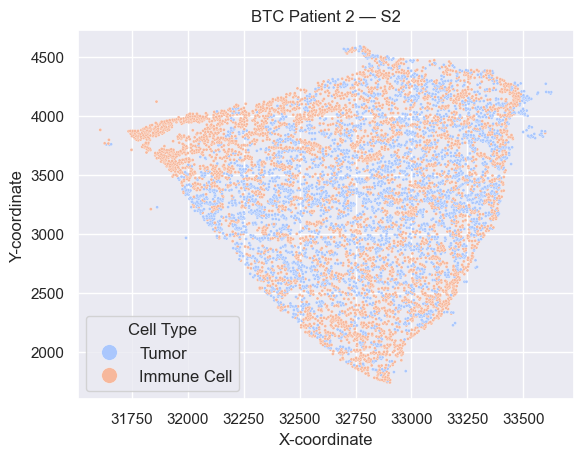

In [33]:
# Plot sample
sns.set_theme(style='darkgrid')  # Set the aesthetic style of the plots
sns.scatterplot(data=btc_pt2_s2, x='x_centroid_um', y='y_centroid_um', s=5, marker='o', hue='tumor_immune', palette='coolwarm')
plt.xlabel('X-coordinate')  # Optional: Set the x-axis label
plt.ylabel('Y-coordinate')  # Optional: Set the y-axis label
plt.title('BTC Patient 2 — S2')  # Optional: Set the plot title
plt.savefig('/Users/emmadyer/Desktop/PROJECTS/BTC/figures/BTC_PT2_S2.png', dpi=300)
# Customize the legend
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Tumor' if label == '0' else 'Immune Cell' for label in labels]
plt.legend(handles, labels, title='Cell Type', markerscale=5, fontsize=12)
plt.show()

In [23]:
def plot_cell_distribution(points, labels, title, ax=None):
    """Helper function to plot cell distributions"""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
    
    # Create scatter plot with different colors for each cell type
    colors = {1: 'red', 0: 'blue'}
    for cell_type in np.unique(labels):
        mask = labels == cell_type
        ax.scatter(points[mask, 0], points[mask, 1], 
                c=colors[cell_type], alpha=0.6, label=cell_type)
    
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    return ax

In [30]:
# Example usage:
coordinates = btc_pt2_s2[['x_centroid_um', 'y_centroid_um']].to_numpy()
cell_labels = btc_pt2_s2['tumor_immune'].values

np.random.seed(42)

simulator = TumorCellSimulator(coordinates, cell_labels)

n_points_per_type = {
    0: 4200,
    1: 3500
}

# Raw Data Simulation

raw_points, raw_labels = simulator.simulate_raw(n_points_per_type=n_points_per_type,
                                                     noise_level=0.1)


# 2. Mixed/Tuned Simulation with different parameter sets
# Default parameters
mixed_points_default, mixed_labels_default = simulator.simulate(
    n_points_per_type=n_points_per_type,
    mode='mixed',
    component_ratio=0.7,
    n_components=3,
    overlap_density=0.5,
    interaction_scale=0.3
)


# 1. High immune cell infiltration
high_infiltration_params = {
    ('tumor', 'tumor'): {'range': 8.0, 'attraction': 2.0, 'repulsion': 1.5},
    ('immune', 'immune'): {'range': 12.0, 'attraction': 0.5, 'repulsion': 1.0},
    ('tumor', 'immune'): {'range': 15.0, 'attraction': 1.5, 'repulsion': 0.8}
}

# 2. Immune exclusion
immune_exclusion_params = {
    ('tumor', 'tumor'): {'range': 8.0, 'attraction': 2.0, 'repulsion': 1.5},
    ('immune', 'immune'): {'range': 10.0, 'attraction': 1.0, 'repulsion': 1.0},
    ('tumor', 'immune'): {'range': 12.0, 'attraction': 0.2, 'repulsion': 2.5}
}

# 1. High immune cell infiltration:
high_immune_points, high_immune_labels = simulator.simulate(
    n_points_per_type=n_points_per_type,
    interaction_params=high_infiltration_params,
    overlap_density=0.7,
    interaction_scale=0.6
)

# 2. Immune exclusion:
immune_exclusion_points, immune_exclusion_labels = simulator.simulate(
    n_points_per_type=n_points_per_type,
    interaction_params=immune_exclusion_params,
    overlap_density=0.3,
    interaction_scale=0.2
)

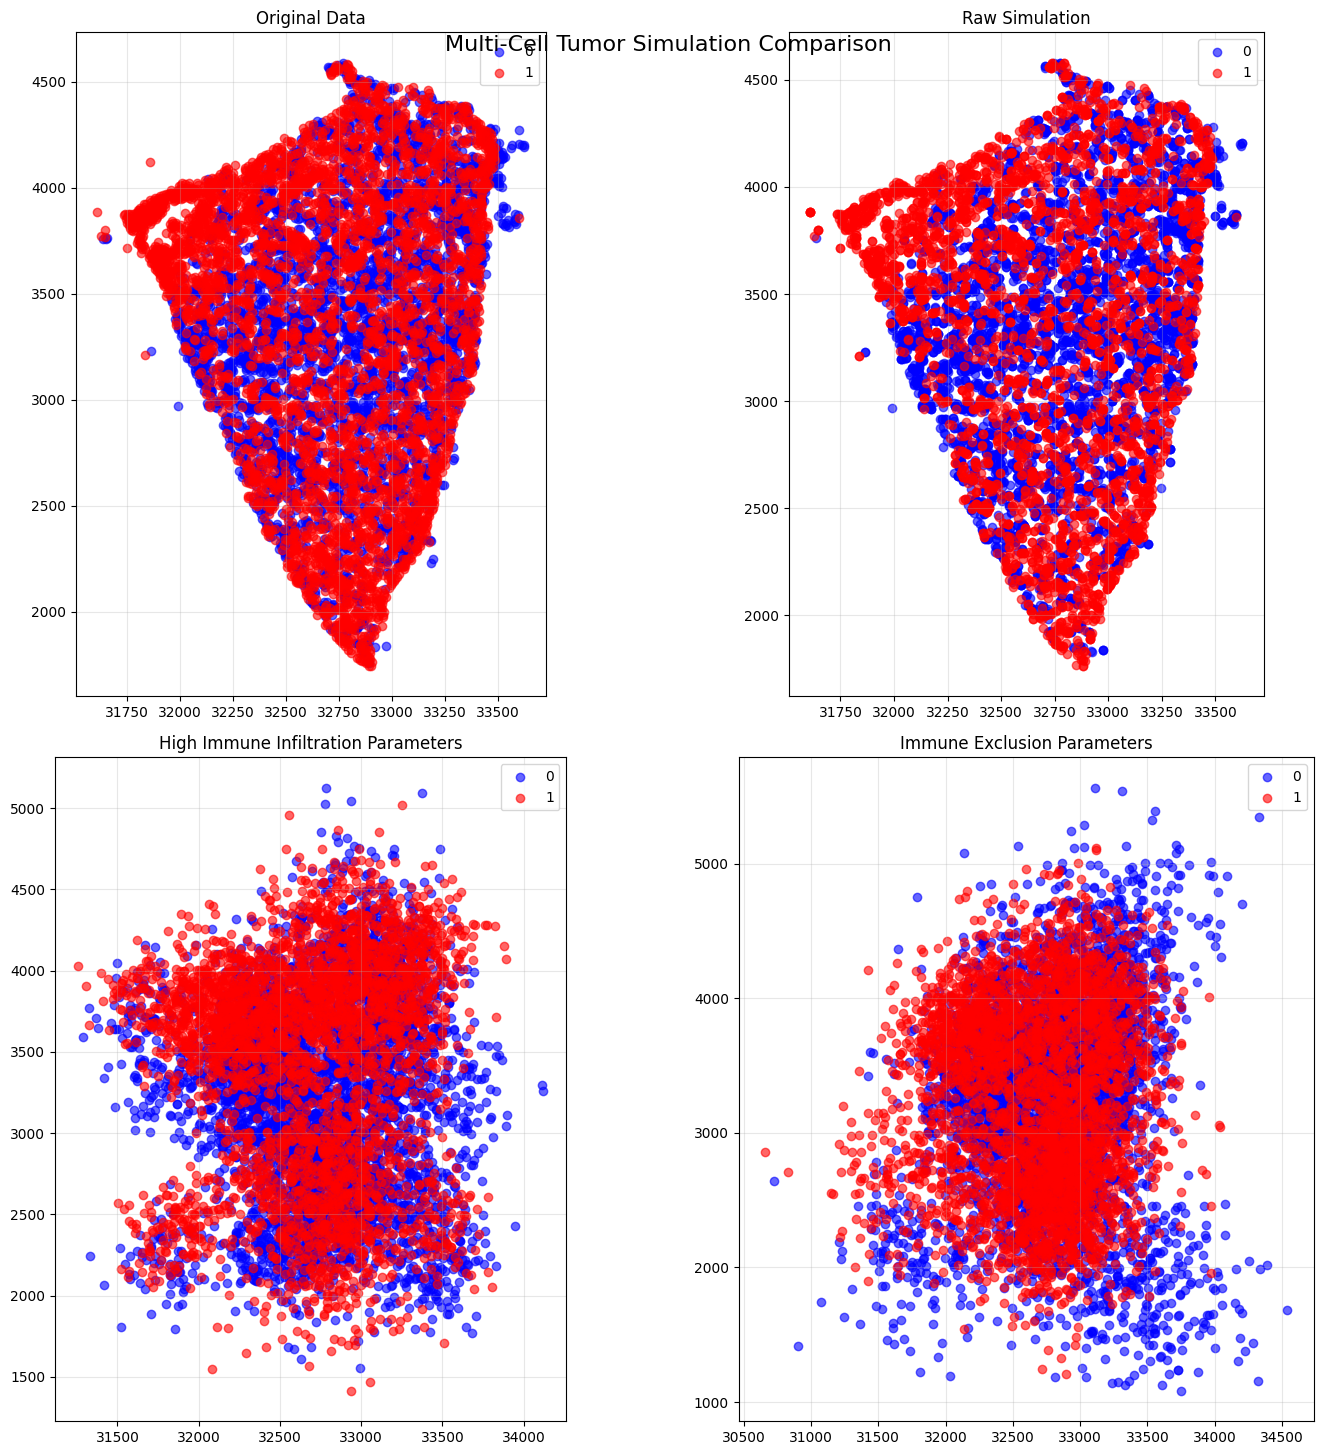


Original Data Statistics:

Immune CELLS:
Count: 3587
Mean position: (32792.85, 3332.61)
Std deviation: (373.27, 573.73)
Mean distance to nearest neighbor: 13.24

Tumor CELLS:
Count: 4365
Mean position: (32709.05, 3359.83)
Std deviation: (429.54, 692.36)
Mean distance to nearest neighbor: 13.35

Raw Simulation Statistics:

Immune CELLS:
Count: 4200
Mean position: (32795.19, 3327.26)
Std deviation: (372.61, 576.21)
Mean distance to nearest neighbor: 5.09

Tumor CELLS:
Count: 3500
Mean position: (32691.76, 3344.84)
Std deviation: (435.51, 685.37)
Mean distance to nearest neighbor: 7.81

High Immune Infiltration Parameters Statistics:

Immune CELLS:
Count: 4200
Mean position: (32749.58, 3193.73)
Std deviation: (461.48, 614.28)
Mean distance to nearest neighbor: 17.89

Tumor CELLS:
Count: 3500
Mean position: (32673.77, 3410.59)
Std deviation: (489.30, 681.81)
Mean distance to nearest neighbor: 19.72

Immune Exclusion Parameters Statistics:

Immune CELLS:
Count: 4200
Mean position: (32800.6

In [32]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Multi-Cell Tumor Simulation Comparison', fontsize=16, y=0.95)

# Plot original data
# Convert DataFrame to NumPy array
points = btc_pt2_s2[['x_centroid_um', 'y_centroid_um']].to_numpy()
plot_cell_distribution(points, cell_labels, 
                      'Original Data', axes[0, 0])

# Plot raw simulation
plot_cell_distribution(raw_points, raw_labels,
                      'Raw Simulation', axes[0, 1])

# Plot default mixed simulation
plot_cell_distribution(high_immune_points, high_immune_labels,
                      'High Immune Infiltration Parameters', axes[1, 0])

# Plot custom mixed simulation
plot_cell_distribution(immune_exclusion_points, immune_exclusion_labels,
                      'Immune Exclusion Parameters', axes[1, 1])

plt.tight_layout()
plt.show()

# Print some statistics about the distributions
def print_distribution_stats(points, labels, title):
    print(f"\n{title} Statistics:")
    labels = np.where(labels == 0, 'Immune', 'Tumor')
    for cell_type in np.unique(labels):
        mask = labels == cell_type
        cell_points = points[mask]
        print(f"\n{cell_type} CELLS:")
        print(f"Count: {np.sum(mask)}")
        print(f"Mean position: ({cell_points[:, 0].mean():.2f}, {cell_points[:, 1].mean():.2f})")
        print(f"Std deviation: ({cell_points[:, 0].std():.2f}, {cell_points[:, 1].std():.2f})")
        
        # Calculate average distance to nearest neighbor of same type
        from scipy.spatial import cKDTree
        tree = cKDTree(cell_points)
        distances, _ = tree.query(cell_points, k=2)  # k=2 to get nearest neighbor (first point is self)
        print(f"Mean distance to nearest neighbor: {distances[:, 1].mean():.2f}")

# Print statistics for all distributions
print_distribution_stats(points, cell_labels, "Original Data")
print_distribution_stats(raw_points, raw_labels, "Raw Simulation")
print_distribution_stats(high_immune_points, high_immune_labels, "High Immune Infiltration Parameters")
print_distribution_stats(immune_exclusion_points, immune_exclusion_labels, "Immune Exclusion Parameters")

fig.savefig('/Users/emmadyer/Desktop/PROJECTS/BTC/figures/Multi_Cell_Tumor_Simulation_Comparison.png', dpi=300)